### `Instagram Influencers Analysis – Data Cleaning, Preprocessing & Exploratory Data Analysis`

`Description:`

* In this part of the project, I focused on understanding and preparing Instagram influencers data for analysis. The objective was to clean raw social media metrics, preprocess them for consistency, select relevant features, and perform exploratory data analysis (EDA) to identify trends in influencer performance and audience engagement.

* The dataset contains information such as influencer rank, influence score, total posts, followers count, average likes, recent engagement rate (60-day), total likes, and country. Since the data includes metrics represented in different formats (such as k, m, b, and percentage values) and contains missing or inconsistent entries, thorough data cleaning and preprocessing were required before conducting meaningful analysis.

* Through EDA, key insights were derived regarding the relationship between followers and engagement, country-wise influencer distribution, and how recent performance differs from overall popularity. This analysis helps brands and marketers make data-driven decisions when selecting influencers and understanding engagement behavior on Instagram.

## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## Load Dataset

In [2]:
# Creating database connection
conn = psycopg2.connect(
    host = "localhost",
    database = "internprojects",
    password = "2526",
    user = "postgres",
    port = "5432"
)

In [3]:
# Checking tables present in the database
tables = pd.read_sql_query("SELECT table_name FROM information_schema.tables WHERE table_schema = 'public' ", conn)
tables

,table_name
0,top_insta_influencers
1,top_insta_influencers_
2,top_insta_influencers_data


In [4]:
# fetch tcs_stock_history.
df = pd.read_sql('SELECT * FROM "top_insta_influencers_"; ', conn)
df.head()

,rank,channel_info,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
0,1,instagram,50,High,8.31k,698m,327k,0.05%,327k,2.72b,United States,Feb-12
1,2,cristiano,61,High,4.0k,670m,8.7m,1.30%,6.5m,34.80b,Portugal,May-12
2,3,leomessi,47,High,1.45k,511m,6.8m,1.33%,4.4m,9.86b,Spain,Jun-13
3,4,selenagomez,40,Medium,2.15k,415m,6.2m,1.49%,3.3m,13.33b,United States,Jul-13
4,5,kyliejenner,42,Medium,7.36k,391m,8.3m,2.12%,2.4m,61.09b,United States,Nov-11


## Data Cleaning & Preprocessing

In [5]:
# Copy Dataset
data = df.copy()

In [6]:
data.shape

(200, 12)

In [7]:
# Check for missing values 
data.isnull().sum() 

rank                  0
channel_info          0
influence_score       0
influence_category    0
posts                 0
followers             0
avg_likes             0
engagement_rate       0
new_post_avg_like     0
total_likes           0
country               0
joining_date          0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   rank                200 non-null    int64 
 1   channel_info        200 non-null    object
 2   influence_score     200 non-null    int64 
 3   influence_category  200 non-null    object
 4   posts               200 non-null    object
 5   followers           200 non-null    object
 6   avg_likes           200 non-null    object
 7   engagement_rate     200 non-null    object
 8   new_post_avg_like   200 non-null    object
 9   total_likes         200 non-null    object
 10  country             200 non-null    object
 11  joining_date        200 non-null    object
dtypes: int64(2), object(10)
memory usage: 18.9+ KB


In [9]:
# Drop any duplicate rows if present
data.drop_duplicates(inplace=True)

In [10]:
data.columns

Index(['rank', 'channel_info', 'influence_score', 'influence_category',
       'posts', 'followers', 'avg_likes', 'engagement_rate',
       'new_post_avg_like', 'total_likes', 'country', 'joining_date'],
      dtype='object')

In [11]:
# Change channel_info name 
data.rename(columns={"channel_info":"username"}, inplace=True)

#### Making string values such as 2M into numeric like 2000000
* as we know Mstands for million and K stands for thousand and so on so we wrote a
regex(regular expression that replaces M with 6 zeros, k with 3 zeros and so on)
Weare taking all the columns which have these kind of symbols and at once
converting them

In [12]:
replace = {'b': 'e9', 'm': 'e6', 'k': 'e3', '%': ''}
convert_col = ['posts', 'followers', 'avg_likes', 'engagement_rate',  'new_post_avg_like', 'total_likes']

data[convert_col] = data[convert_col].replace(replace, regex=True).astype(float)
data[convert_col].head()

,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes
0,8310.0,698000000.0,327000.0,0.05,327000.0,2.720000e+09
1,4000.0,670000000.0,8700000.0,1.30,6500000.0,3.480000e+10
2,1450.0,511000000.0,6800000.0,1.33,4400000.0,9.860000e+09
3,2150.0,415000000.0,6200000.0,1.49,3300000.0,1.333000e+10
4,7360.0,391000000.0,8300000.0,2.12,2400000.0,6.109000e+10


In [13]:
# Convert joining_date into datetime data type
data['joining_date'] = pd.to_datetime(data['joining_date'], format='%b-%y')

## Exploratory Data Analysis (EDA)

`1. Summary Statistics`

In [14]:
data.describe()

,rank,influence_score,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,joining_date
count,200.000000,200.00000,200.000000,2.000000e+02,2.000000e+02,200.000000,2.000000e+02,2.000000e+02,200
mean,100.500000,12.70500,6243.855000,9.302650e+07,1.894552e+06,2.637350,2.180771e+06,4.866300e+09,2013-04-28 08:52:48
min,1.000000,3.00000,2.000000,2.910000e+07,1.200000e+03,0.000000,2.400000e+03,0.000000e+00,2010-11-01 00:00:00
25%,50.750000,6.00000,1062.500000,4.490000e+07,4.970000e+05,0.797500,1.895500e+05,1.110000e+09,2012-02-01 00:00:00
50%,100.500000,8.50000,2210.000000,5.695000e+07,1.100000e+06,1.530000,4.331000e+05,2.380000e+09,2012-09-16 00:00:00
75%,150.250000,15.00000,5630.000000,8.032500e+07,2.100000e+06,2.695000,1.100000e+06,4.522500e+09,2014-01-01 00:00:00
max,200.000000,95.00000,125000.000000,6.980000e+08,2.430000e+07,43.550000,2.560000e+08,6.109000e+10,2021-12-01 00:00:00
std,57.879185,11.93104,13705.857612,1.010048e+08,2.721125e+06,4.507993,1.807999e+07,7.707045e+09,NaN


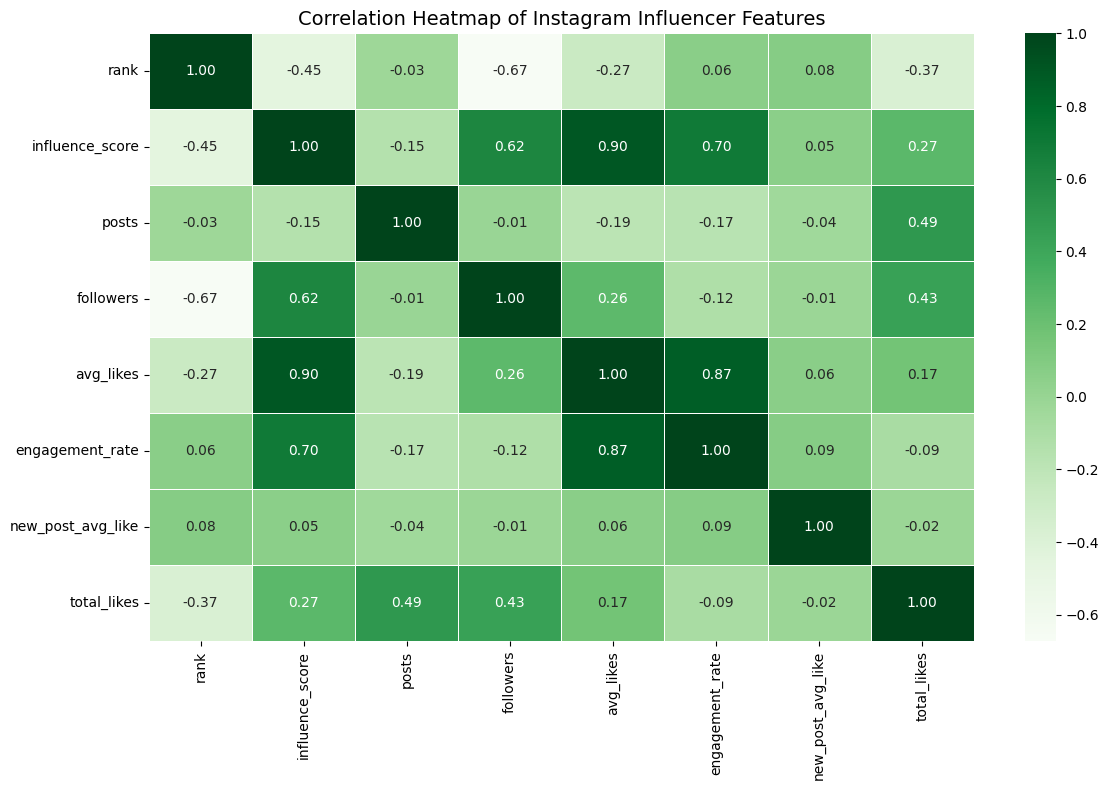

In [15]:
# Correlation Of Features
num_col = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 8))
sns.heatmap(num_col.corr(), annot=True, cmap='Greens', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Instagram Influencer Features', fontsize=14)
plt.tight_layout()
plt.show()

`Summary Statistics`

* The dataset contains 200 influencers with complete numerical data.

* Follower count and total likes are highly skewed, indicating the presence of a few mega-influencers.

* The average engagement rate is ~2.6%, while some influencers achieve very high engagement, showing strong audience interaction.

* Posting activity varies widely, from very low to extremely high post counts.

* Influencers joined the platform between 2010 and 2021, where early joiners generally have higher reach and total likes.

`2. Distribution of Influence Score`

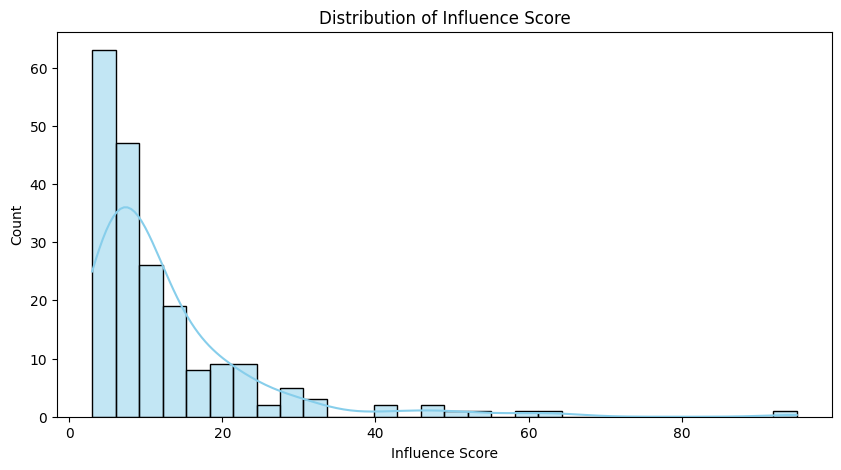

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data['influence_score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Influence Score')
plt.xlabel('Influence Score')
plt.show()

`Distribution of Influence Score – Key Insights`

* The influence score is right-skewed, meaning most influencers have low to medium influence.

* A small number of influencers have very high scores, representing elite or top-tier influencers.

* The majority of scores are concentrated below 20, showing high competition at lower influence levels.

* The long tail indicates that very few influencers dominate overall influence.

`3. Most Active Countries`

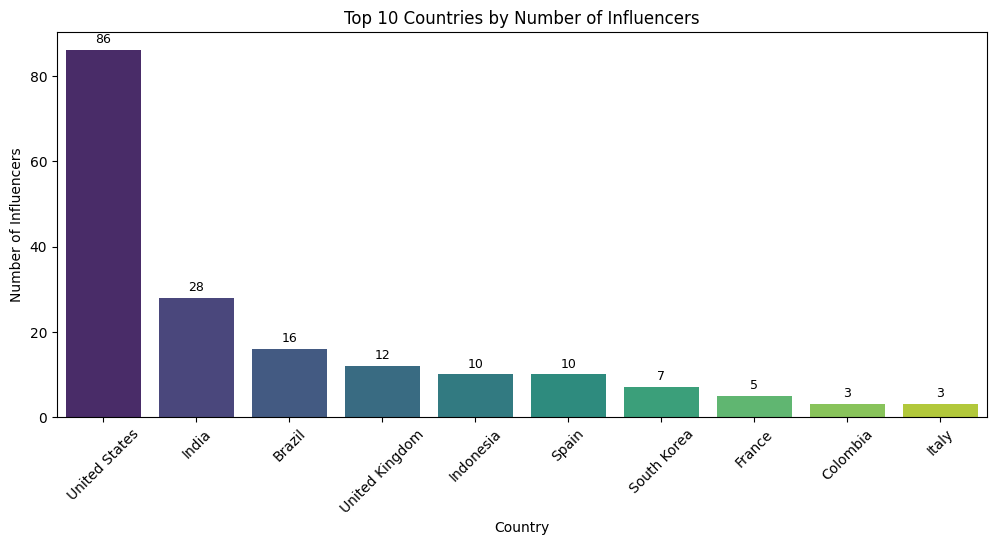

In [17]:
top_countries = data['country'].value_counts().head(10)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis")

# add labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
    
plt.title('Top 10 Countries by Number of Influencers')
plt.xlabel('Country')
plt.ylabel('Number of Influencers')
plt.xticks(rotation=45)
plt.show()

`Top 10 Countries by Number of Influencers – Key Insights`

* The United States dominates with the highest number of influencers, showing a strong creator economy.

* India ranks second, indicating rapid growth in influencer culture.

* Countries like Brazil and the United Kingdom have a moderate influencer presence.

* The remaining countries contribute relatively fewer influencers, showing a concentrated market.

`4. Filtering influencers with an engagement rate above 5%`

In [18]:
high_engagement_df = data[data['engagement_rate'] > 5]
high_engagement_df

,rank,username,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_date
33,34,billieeilish,29,Medium,1030.0,125000000.0,8500000.0,6.80,2200000.0,8.760000e+09,United States,2012-03-01
34,35,lalalalisa_m,23,Low,1190.0,106000000.0,5800000.0,5.47,3200000.0,6.900000e+09,United States,2018-06-01
48,49,roses_are_rosie,19,Low,1180.0,84300000.0,4600000.0,5.46,3100000.0,5.430000e+09,United States,2018-06-01
50,51,sooyaaa__,19,Low,1290.0,80300000.0,4500000.0,5.60,2100000.0,5.810000e+09,South Korea,2018-06-01
55,56,bts.bighitofficial,18,Low,1200.0,78000000.0,4100000.0,5.26,3600000.0,4.920000e+09,South Korea,2015-11-01
62,63,milliebobbybrown,18,Low,710.0,72300000.0,4000000.0,5.53,1900000.0,2.840000e+09,United States,2016-06-01
67,68,thv,55,High,150.0,70100000.0,15400000.0,21.97,7000000.0,2.310000e+09,South Korea,2021-12-01
81,82,tomholland2013,23,Low,1300.0,62900000.0,5200000.0,8.27,2200000.0,6.760000e+09,United Kingdom,2012-05-01
88,89,travisscott,15,Low,3340.0,59900000.0,3000000.0,5.01,2600000.0,1.002000e+10,United States,2012-01-01
95,96,adele,21,Low,500.0,57600000.0,4700000.0,8.16,1900000.0,2.350000e+09,United Kingdom,2015-10-01


`5. Relationship between Followers and Engagement Rate`

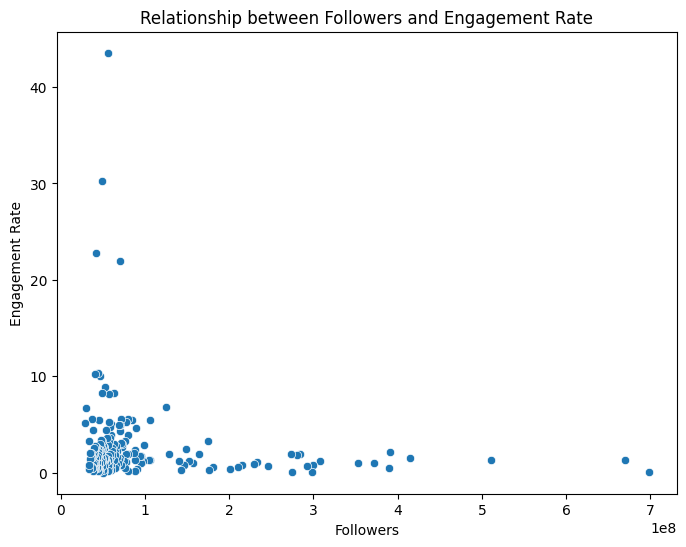

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='followers', y='engagement_rate', data=data)
plt.title('Relationship between Followers and Engagement Rate')
plt.xlabel('Followers')
plt.ylabel('Engagement Rate')
plt.show()

`Followers vs Engagement Rate – Key Insight`

* There is a negative relationship between followers and engagement rate.

* Accounts with fewer followers often show higher engagement, while very large accounts tend to have lower engagement rates.

* This indicates that micro and mid-level influencers usually engage audiences more effectively than mega influencers.

## Feature Engineering

In [20]:
data['joining_month_name'] = data['joining_date'].dt.month_name()  # February
data['joining_year'] = data['joining_date'].dt.year          # 2012

In [21]:
# Creating engagement-related features
data['like_follower_ratio'] = data['total_likes'] / data['followers']
data['post_follower_ratio'] = data['posts'] / data['followers']
data['avg_likes_ratio'] = data['avg_likes'] / data['followers']

In [22]:
data.columns

Index(['rank', 'username', 'influence_score', 'influence_category', 'posts',
       'followers', 'avg_likes', 'engagement_rate', 'new_post_avg_like',
       'total_likes', 'country', 'joining_date', 'joining_month_name',
       'joining_year', 'like_follower_ratio', 'post_follower_ratio',
       'avg_likes_ratio'],
      dtype='object')

In [23]:
features = ['rank', 'username', 'influence_score', 'influence_category', 'posts',
            'followers', 'avg_likes', 'engagement_rate', 'new_post_avg_like',
            'total_likes', 'country', 'joining_month_name', 'joining_year', 'like_follower_ratio',
            'post_follower_ratio']

In [24]:
# Save the cleaned dataset for Tableau / Power BI

data = data[features]

data.to_csv('top_insta_infl_cleaned_data.csv', index=False)

print("Dataset saved successfully")

Dataset saved successfully
